In [1]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test


/Users/richard/Desktop/STL/STL-Dev/STL_main/__init__.py:9: UserWarning: In development mode: Please run 'pip install -e .' in the root directory of the STL repository to properly install the package, its dependencies and enable proper version tracking.
  warnings.warn(


Working on device: mps


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [3]:
N = 256

0.9997000000000001


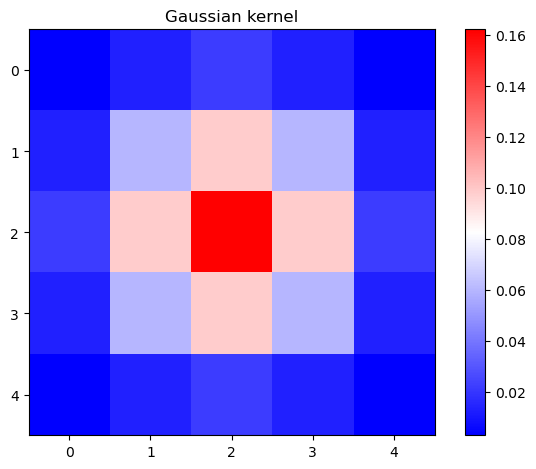

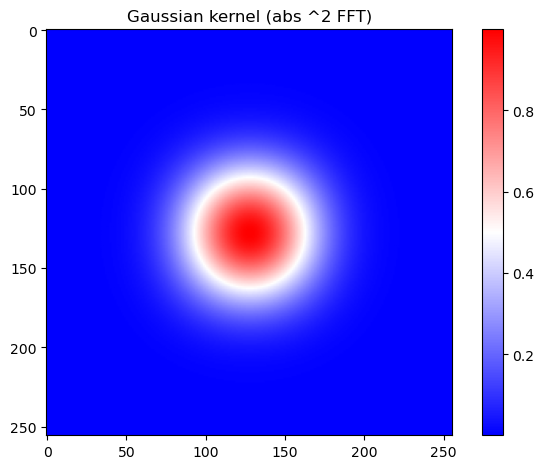

In [4]:
smooth_kernel_gaussian = np.array(
    [
        [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
        [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
        [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
        [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
        [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
    ]
)

print(smooth_kernel_gaussian.sum())

plt.imshow(smooth_kernel_gaussian, cmap='bwr')
plt.title('Gaussian kernel')
plt.colorbar()
plt.tight_layout()
plt.show()

fft_smooth_kernel_gaussian = np.zeros((N, N))
fft_smooth_kernel_gaussian[:smooth_kernel_gaussian.shape[0], :smooth_kernel_gaussian.shape[1]] = smooth_kernel_gaussian
fft_smooth_kernel_gaussian = np.abs(np.fft.fftshift(np.fft.fft2(fft_smooth_kernel_gaussian)))  # Shift the kernel to center the zero-frequency component

plt.imshow(fft_smooth_kernel_gaussian ** 2, cmap='bwr')
plt.title(f'Gaussian kernel (abs ^2 FFT)')
plt.colorbar()
plt.tight_layout()
plt.show()

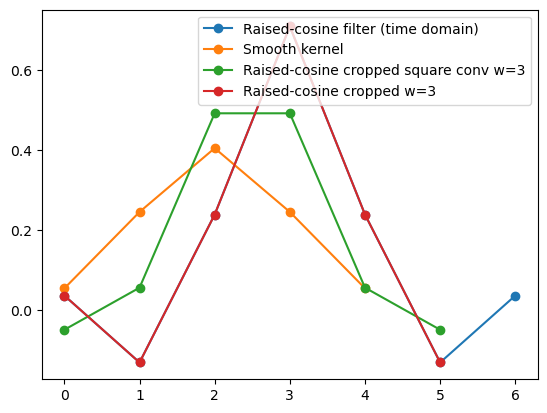

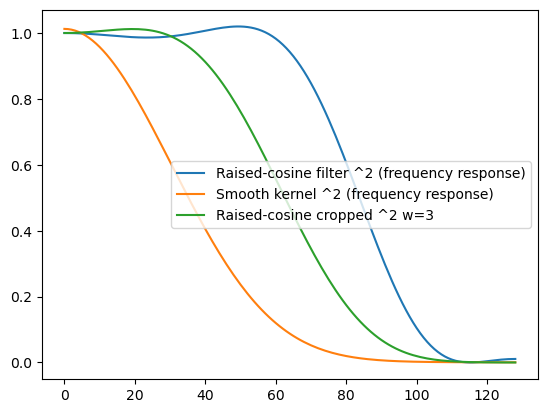

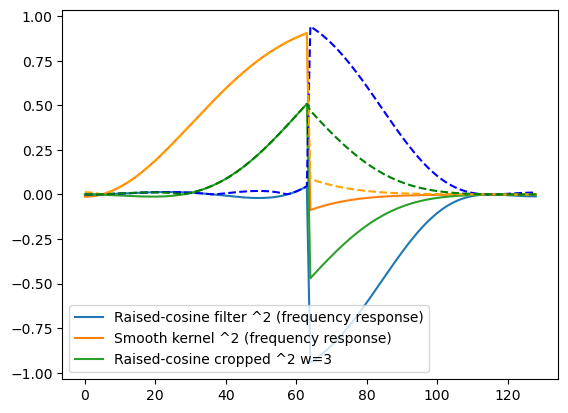

k_err=10.43%
crop_k_err=3.28%
smooth_kernel_err=13.86%
k_loss=-15.74%
crop_k_loss=0.00%
smooth_kernel_loss=20.34%


In [5]:
w = 3
n = 2 * w + 1
factor = .4
bandwidth = .71
beta = 0.35

def raised_cosine_filter(freqs, bandwidth, beta=0.25):
    # Raised-cosine filter implementation
    # define at https://en.wikipedia.org/wiki/Raised-cosine_filter

    stretch = bandwidth ** (-1)
    tide_filt = np.zeros_like(freqs)
    shift_freqs = stretch * freqs
    msk1 = np.logical_and(np.abs(shift_freqs) > (1 - beta) / 2, 
                          np.abs(shift_freqs) <= (1 + beta) / 2)
    tide_filt[msk1] = 0.5 * (1 + np.cos((np.pi / beta) * (np.abs(shift_freqs[msk1]) - (1 - beta) / 2)))
    msk2 = np.abs(shift_freqs) <= (1 - beta) / 2
    tide_filt[msk2] = 1.
    return tide_filt


k = np.real(np.fft.fftshift(np.fft.ifft(raised_cosine_filter(np.fft.fftfreq(n), bandwidth=bandwidth, beta=beta))))
_crop_k = k[n//2-w:n//2+w]
crop_k = .5 * (_crop_k + _crop_k[::-1])  # Symmetrize the cropped kernel
crop_k /= crop_k.sum()

plt.plot(k, label='Raised-cosine filter (time domain)', marker='o')
plt.plot(smooth_kernel_gaussian[2,:]/factor, label='Smooth kernel', marker='o')
plt.plot(crop_k, label=f'Raised-cosine cropped square conv w={w}', marker='o')
plt.plot(_crop_k, label=f'Raised-cosine cropped w={w}', marker='o')
plt.legend()
plt.show()


long_smooth_kernel = np.zeros((N,))
long_smooth_kernel[:smooth_kernel_gaussian.shape[1]] = smooth_kernel_gaussian[2,:] / factor
long_k = np.zeros((N,))
long_k[:n] = k
long_crop_k = np.zeros((N,))
#long_crop_k[:2*w+1] = crop_k
long_crop_k[:2*w] = crop_k

plt.plot(np.abs(np.fft.fft(long_k)[:long_k.shape[0]//2+1])**2, label='Raised-cosine filter ^2 (frequency response)')
plt.plot(np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2, label='Smooth kernel ^2 (frequency response)')
plt.plot(np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2, label=f'Raised-cosine cropped ^2 w={w}')
plt.legend()
plt.show()


target = np.ones((N,))
target[N//4:] = 0

plt.plot(target[:N//2+1] - np.abs(np.fft.fft(long_k)[:long_k.shape[0]//2+1])**2, label='Raised-cosine filter ^2 (frequency response)')
plt.plot(target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2, label='Smooth kernel ^2 (frequency response)')
plt.plot(target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2, label=f'Raised-cosine cropped ^2 w={w}')

plt.plot(np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_k)[:long_k.shape[0]//2+1])**2), ls='--', c='blue')
plt.plot(np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2), ls='--', c='orange')
plt.plot(np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2), ls='--', c='green')
plt.legend()
plt.show()


k_err = (np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_k)[:long_k.shape[0]//2+1])**2)**2).mean()
smooth_kernel_err = (np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2)**2).mean()
crop_k_err = (np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2)**2).mean()

print('k_err={:.2f}%\ncrop_k_err={:.2f}%\nsmooth_kernel_err={:.2f}%'.format(100*k_err, 100*crop_k_err, 100*smooth_kernel_err))


k_loss = (target[:N//2+1] - np.abs(np.fft.fft(long_k)[:long_k.shape[0]//2+1])**2).mean()
smooth_kernel_loss = (target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2).mean()
crop_k_loss = (target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2).mean()

print('k_loss={:.2f}%\ncrop_k_loss={:.2f}%\nsmooth_kernel_loss={:.2f}%'.format(100*k_loss, 100*crop_k_loss, 100*smooth_kernel_loss))

1.0


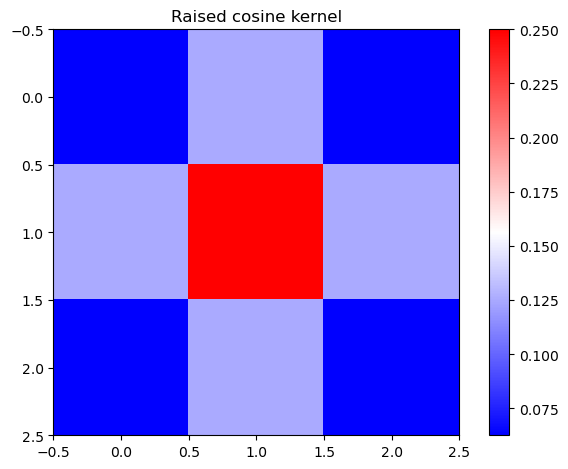

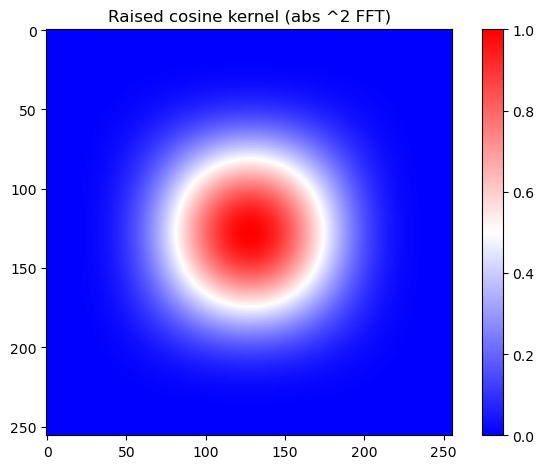

In [6]:
if False:
    smooth_kernel_raise_cosine = np.array(
        [
            [ 2.0286e-03, -2.1063e-07, -1.3166e-02, -2.2515e-02, -1.3166e-02, -2.1063e-07,  2.0286e-03],
            [-2.1063e-07,  2.1870e-11,  1.3670e-06,  2.3377e-06,  1.3670e-06,  2.1870e-11, -2.1063e-07],
            [-1.3166e-02,  1.3670e-06,  8.5452e-02,  1.4613e-01,  8.5452e-02,  1.3670e-06, -1.3166e-02],
            [-2.2515e-02,  2.3377e-06,  1.4613e-01,  2.4988e-01,  1.4613e-01,  2.3377e-06, -2.2515e-02],
            [-1.3166e-02,  1.3670e-06,  8.5452e-02,  1.4613e-01,  8.5452e-02,  1.3670e-06, -1.3166e-02],
            [-2.1063e-07,  2.1870e-11,  1.3670e-06,  2.3377e-06,  1.3670e-06,  2.1870e-11, -2.1063e-07],
            [ 2.0286e-03, -2.1063e-07, -1.3166e-02, -2.2515e-02, -1.3166e-02, -2.1063e-07,  2.0286e-03]
        ]
    )
elif False:
    smooth_kernel_raise_cosine = np.array(
        [
            [ 0.25, 0.25],
            [ 0.25, 0.25]
        ]
    )
elif True:
    smooth_kernel_raise_cosine = np.array(
        [
            [ 0.0625, 0.125, 0.0625],
            [  0.125,  0.25,  0.125],
            [ 0.0625, 0.125, 0.0625]
        ]
    )
else:
    smooth_kernel_raise_cosine = np.array(
        [
            [ 0.00045404, -0.00298377, -0.00812433, -0.00812433, -0.00298377,  0.00045404],
            [-0.00298377,  0.0196083 ,  0.05339029,  0.05339029,  0.0196083 , -0.00298377],
            [-0.00812433,  0.05339029,  0.1453733 ,  0.1453733 ,  0.05339029, -0.00812433],
            [-0.00812433,  0.05339029,  0.1453733 ,  0.1453733 ,  0.05339029, -0.00812433],
            [-0.00298377,  0.0196083 ,  0.05339029,  0.05339029,  0.0196083 , -0.00298377],
            [ 0.00045404, -0.00298377, -0.00812433, -0.00812433, -0.00298377,  0.00045404]
        ]
    )

print(smooth_kernel_raise_cosine.sum())

plt.imshow(smooth_kernel_raise_cosine, cmap='bwr')
plt.title('Raised cosine kernel')
plt.colorbar()
plt.tight_layout()
plt.show()

fft_smooth_kernel_raise_cosine = np.zeros((N, N))
fft_smooth_kernel_raise_cosine[:smooth_kernel_raise_cosine.shape[0], :smooth_kernel_raise_cosine.shape[1]] = smooth_kernel_raise_cosine
fft_smooth_kernel_raise_cosine = np.abs(np.fft.fftshift(np.fft.fft2(fft_smooth_kernel_raise_cosine)))  # Shift the kernel to center the zero-frequency component

plt.imshow(fft_smooth_kernel_raise_cosine ** 2, cmap='bwr')
plt.title(f'Raised cosine kernel (abs ^2 FFT)')
plt.colorbar()
plt.tight_layout()
plt.show()

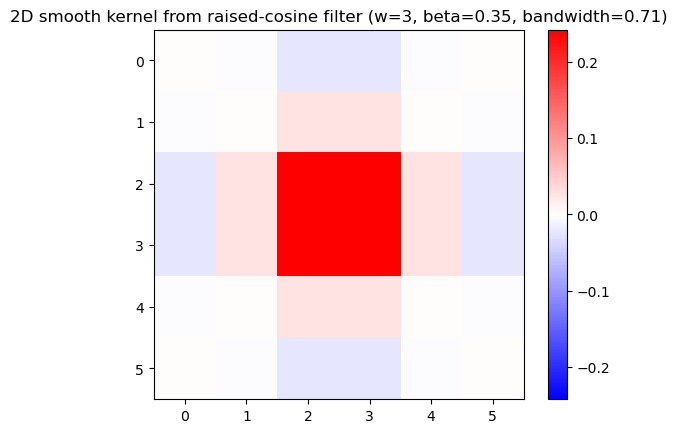

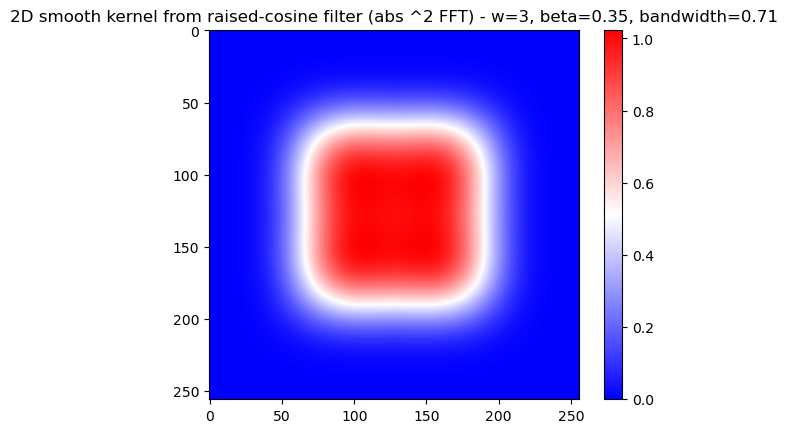

crop_k_err=3.23%
crop_k_loss=0.00%


In [7]:
w = 3
n = 2*w+1
beta = 0.35
bandwidth = .71
N = 256

k = np.real(np.fft.fftshift(np.fft.ifft(raised_cosine_filter(np.fft.fftfreq(n), bandwidth=bandwidth, beta=beta))))
#crop_k = k[n//2-w:n//2+w+1]
_crop_k = k[n//2-w:n//2+w]
crop_k = .5 * (_crop_k + _crop_k[::-1])  # Symmetrize the cropped kernel
crop_k /= crop_k.sum()

smooth_kernel_raised_cosine = crop_k[None, :] * crop_k[:, None]
plt.imshow(smooth_kernel_raised_cosine, cmap='bwr', 
           vmin=-smooth_kernel_raised_cosine.max(), 
           vmax=smooth_kernel_raised_cosine.max())
plt.colorbar()
plt.title(f'2D smooth kernel from raised-cosine filter (w={w}, beta={beta}, bandwidth={bandwidth})')
plt.show()

long_smooth_kernel_raised_cosine = np.zeros((N, N))
long_smooth_kernel_raised_cosine[:smooth_kernel_raised_cosine.shape[0], :smooth_kernel_raised_cosine.shape[1]] = smooth_kernel_raised_cosine
plt.imshow(np.abs(np.fft.fftshift(np.fft.fft2(long_smooth_kernel_raised_cosine))**2), cmap='bwr')
plt.colorbar()
plt.title(f'2D smooth kernel from raised-cosine filter (abs ^2 FFT) - w={w}, beta={beta}, bandwidth={bandwidth}')
plt.show()

#smooth_kernel_err = (np.abs(target[:N//2+1, None] * target[None, :N//2+1] - np.abs(np.fft.fft2(smooth_kernel_gaussian)[:N//2+1, :N//2+1])**2)**2).mean()
crop_k_err = (np.abs(target[:N//2+1, None] * target[None, :N//2+1] - np.abs(np.fft.fft2(long_smooth_kernel_raised_cosine)[:long_smooth_kernel_raised_cosine.shape[0]//2+1, 
                                                                                            :long_smooth_kernel_raised_cosine.shape[1]//2+1])**2)**2).mean()

print('crop_k_err={:.2f}%'.format(100*crop_k_err))


#smooth_kernel_loss = (target[:N//2+1, None] * target[None, :N//2+1] - np.abs(np.fft.fft2(smooth_kernel_gaussian)[:N//2+1, :N//2+1])**2).mean()
crop_k_loss = (target[:N//2+1, None] * target[None, :N//2+1] - np.abs(np.fft.fft2(long_smooth_kernel_raised_cosine)[:N//2+1, :N//2+1])**2).mean()

print('crop_k_loss={:.2f}%'.format(100*crop_k_loss))

In [8]:
smooth_kernel_raised_cosine.sum()

np.float64(0.9999999999999998)

In [9]:
# change numpy print options to increase number of columns printed
np.set_printoptions(linewidth=200)
smooth_kernel_raised_cosine

array([[ 0.00238073, -0.00275097, -0.02402609, -0.02402609, -0.00275097,  0.00238073],
       [-0.00275097,  0.0031788 ,  0.0277626 ,  0.0277626 ,  0.0031788 , -0.00275097],
       [-0.02402609,  0.0277626 ,  0.2424694 ,  0.2424694 ,  0.0277626 , -0.02402609],
       [-0.02402609,  0.0277626 ,  0.2424694 ,  0.2424694 ,  0.0277626 , -0.02402609],
       [-0.00275097,  0.0031788 ,  0.0277626 ,  0.0277626 ,  0.0031788 , -0.00275097],
       [ 0.00238073, -0.00275097, -0.02402609, -0.02402609, -0.00275097,  0.00238073]])

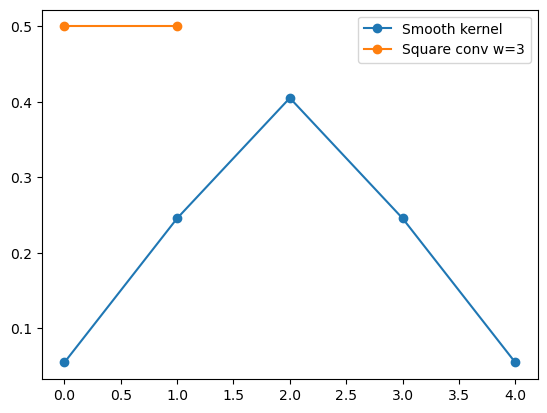

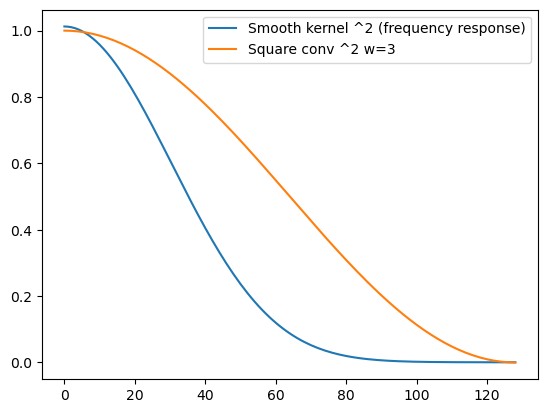

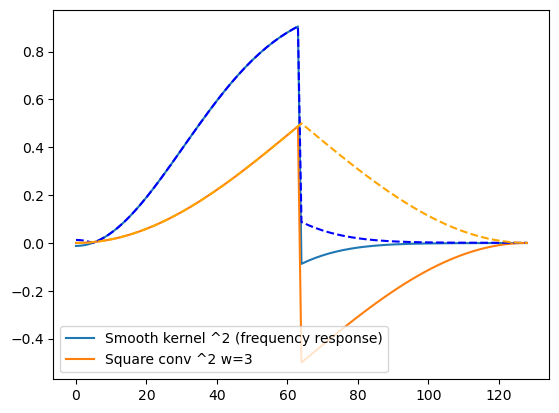

crop_k_err=5.63%
smooth_kernel_err=13.86%
crop_k_loss=-0.39%
smooth_kernel_loss=20.34%


In [10]:
crop_k = .5 * np.array([1, 1])

plt.plot(smooth_kernel_gaussian[2,:]/factor, label='Smooth kernel', marker='o')
plt.plot(crop_k, label=f'Square conv w={w}', marker='o')
plt.legend()
plt.show()


long_smooth_kernel = np.zeros((N,))
long_smooth_kernel[:smooth_kernel_gaussian.shape[1]] = smooth_kernel_gaussian[2,:] / factor
long_crop_k = np.zeros((N,))
long_crop_k[:2] = crop_k

plt.plot(np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2, label='Smooth kernel ^2 (frequency response)')
plt.plot(np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2, label=f'Square conv ^2 w={w}')
plt.legend()
plt.show()


target = np.ones((N,))
target[N//4:] = 0

plt.plot(target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2, label='Smooth kernel ^2 (frequency response)')
plt.plot(target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2, label=f'Square conv ^2 w={w}')

plt.plot(np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2), ls='--', c='blue')
plt.plot(np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2), ls='--', c='orange')

plt.legend()
plt.show()


smooth_kernel_err = (np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2)**2).mean()
crop_k_err = (np.abs(target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2)**2).mean()

print('crop_k_err={:.2f}%\nsmooth_kernel_err={:.2f}%'.format(100*crop_k_err, 100*smooth_kernel_err))

smooth_kernel_loss = (target[:N//2+1] - np.abs(np.fft.fft(long_smooth_kernel)[:long_smooth_kernel.shape[0]//2+1])**2).mean()
crop_k_loss = (target[:N//2+1] - np.abs(np.fft.fft(long_crop_k)[:long_crop_k.shape[0]//2+1])**2).mean()

print('crop_k_loss={:.2f}%\nsmooth_kernel_loss={:.2f}%'.format(100*crop_k_loss, 100*smooth_kernel_loss))

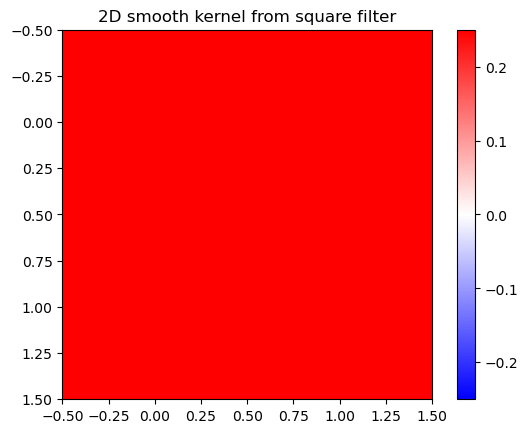

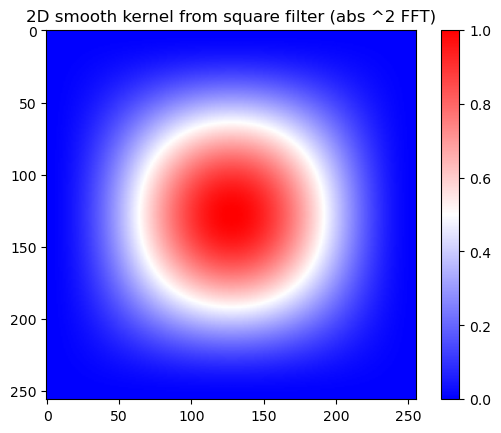

In [11]:
N = 256

crop_k = .5 * np.array([1, 1])

smooth_kernel_raised_cosine = crop_k[None, :] * crop_k[:, None]
plt.imshow(smooth_kernel_raised_cosine, cmap='bwr', 
           vmin=-smooth_kernel_raised_cosine.max(), 
           vmax=smooth_kernel_raised_cosine.max())
plt.colorbar()
plt.title(f'2D smooth kernel from square filter')
plt.show()

long_smooth_kernel_raised_cosine = np.zeros((N, N))
long_smooth_kernel_raised_cosine[:smooth_kernel_raised_cosine.shape[0], :smooth_kernel_raised_cosine.shape[1]] = smooth_kernel_raised_cosine
plt.imshow(np.abs(np.fft.fftshift(np.fft.fft2(long_smooth_kernel_raised_cosine))**2), cmap='bwr')
plt.colorbar()
plt.title(f'2D smooth kernel from square filter (abs ^2 FFT)')
plt.show()